### Computing Hellinger Distance between LOB Snapshots

In [ ]:
! pip install ruptures
! pip install gcsfs

In [2]:


import ruptures as rpt  # our package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR, ccf
import sys
import os
import logging

from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

sys.path.append("/home/jovyan/research/research_utils/helpers")
from GCData import GCData
from Bars import get_time_bars,get_alt_bars

sys.path.append("/home/jovyan/data_warehouse/")
from dw_src.api.features_api import get_features_df, load_features

In [3]:
ob_data = GCData(
    datatype="book",
    exchange="ftx",
    symbol="BTCUSDP",
    end = datetime.strptime("2022-5-31","%Y-%m-%d"),
    start= datetime.strptime("2022-5-30","%Y-%m-%d")
)
orderbook = ob_data.get_data()

/opt/conda/lib/python3.8/site-packages/google/auth/_default.py:70: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. We recommend you rerun `gcloud auth application-default login` and make sure a quota project is added. Or you can use service accounts instead. For more information about service accounts, see https://cloud.google.com/docs/authentication/
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [210]:
bidp,bids,bbt,askp,asks,abt,obi=ob_data.partition_ob(orderbook)
bbt

,Level0,Level1,Level2,Level3,Level4,Level5,Level6,Level7,Level8,Level9,...,Level16,Level17,Level18,Level19,Level20,Level21,Level22,Level23,Level24,midprice
time,,,,,,,,,,,,,,,,,,,,,
2022-05-30 00:00:00.832187+00:00,148829.7525,235512.8885,292549.8681,371386.7115,434013.6067,568937.1267,776008.1088,886898.1110,962474.6648,1.303644e+06,...,2.574616e+06,3.190156e+06,3.191580e+06,3.432867e+06,3.510073e+06,3.510102e+06,3.673052e+06,3.734027e+06,3.901103e+06,29445.5
2022-05-30 00:00:00.912155+00:00,148829.7525,235512.8885,292549.8681,371386.7115,434013.6067,568937.1267,776008.1088,886898.1110,962474.6648,1.303644e+06,...,2.574540e+06,3.190079e+06,3.191503e+06,3.426791e+06,3.503996e+06,3.504026e+06,3.660974e+06,3.721948e+06,3.889024e+06,29445.5
2022-05-30 00:00:00.938175+00:00,148829.7525,235512.8885,292549.8681,371386.7115,434013.6067,568937.1267,776008.1088,886898.1110,962474.6648,1.303644e+06,...,2.582849e+06,3.198388e+06,3.199813e+06,3.435100e+06,3.512305e+06,3.512335e+06,3.669283e+06,3.730257e+06,3.897333e+06,29445.5
2022-05-30 00:00:00.962433+00:00,148829.7525,235512.8885,292549.8681,371386.7115,434013.6067,568937.1267,776008.1088,886898.1110,962474.6648,1.303644e+06,...,2.583585e+06,3.199124e+06,3.200548e+06,3.435836e+06,3.513041e+06,3.513071e+06,3.670019e+06,3.730993e+06,3.898069e+06,29445.5
2022-05-30 00:00:00.990431+00:00,147357.5025,234040.6385,291077.6181,369914.4615,432541.3567,567464.8767,774535.8588,885425.8610,961002.4148,1.302172e+06,...,2.582112e+06,3.197652e+06,3.199076e+06,3.450136e+06,3.527341e+06,3.527371e+06,3.684319e+06,3.745293e+06,3.912369e+06,29445.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-05-30 23:59:59.670152+00:00,313806.5270,338682.0630,455672.7174,500395.0966,601766.0118,652283.3094,687759.1403,888362.7239,977355.9894,1.088614e+06,...,1.698938e+06,1.815930e+06,2.142448e+06,2.943510e+06,3.093940e+06,3.354047e+06,3.689888e+06,4.680266e+06,4.937714e+06,31730.5
2022-05-30 23:59:59.695646+00:00,313806.5270,338682.0630,455672.7174,500395.0966,601766.0118,652283.3094,687759.1403,888362.7239,977355.9894,1.088614e+06,...,1.698938e+06,1.815930e+06,2.142448e+06,2.943510e+06,3.093940e+06,3.354047e+06,3.689888e+06,4.682875e+06,4.940323e+06,31730.5
2022-05-30 23:59:59.746053+00:00,313806.5270,338682.0630,455672.7174,500395.0966,601766.0118,652283.3094,687759.1403,888362.7239,977355.9894,1.088614e+06,...,1.698938e+06,1.815930e+06,2.142448e+06,2.943510e+06,3.093940e+06,3.354047e+06,3.696736e+06,4.689724e+06,4.947172e+06,31730.5


In [211]:
bbt=bbt[bbt.columns[:-15]]
new_bbt=[str(i+"_B") for i in bbt.columns]
bbt=bbt.rename(columns=dict(zip(bbt.columns,new_bbt)))
abt=abt[abt.columns[:-15]]
new_abt=[str(i+"_A") for i in abt.columns]
abt=abt.rename(columns=dict(zip(abt.columns,new_abt)))

In [212]:
lob=pd.concat([bbt[bbt.columns[::-1]],abt],axis=1)
lob

,Level10_B,Level9_B,Level8_B,Level7_B,Level6_B,Level5_B,Level4_B,Level3_B,Level2_B,Level1_B,...,Level1_A,Level2_A,Level3_A,Level4_A,Level5_A,Level6_A,Level7_A,Level8_A,Level9_A,Level10_A
time,,,,,,,,,,,,,,,,,,,,,
2022-05-30 00:00:00.832187+00:00,1.383083e+06,1.303644e+06,962474.6648,886898.1110,776008.1088,568937.1267,434013.6067,371386.7115,292549.8681,235512.8885,...,139699.2035,156855.6083,218630.7756,295627.8006,357949.0617,439949.3201,537951.2323,686328.7027,838611.0527,924428.1631
2022-05-30 00:00:00.912155+00:00,1.383083e+06,1.303644e+06,962474.6648,886898.1110,776008.1088,568937.1267,434013.6067,371386.7115,292549.8681,235512.8885,...,139699.2035,156855.6083,218630.7756,289625.8906,351947.1517,433947.4101,531949.3223,680326.7927,832609.1427,912923.8723
2022-05-30 00:00:00.938175+00:00,1.383180e+06,1.303644e+06,962474.6648,886898.1110,776008.1088,568937.1267,434013.6067,371386.7115,292549.8681,235512.8885,...,139699.2035,156855.6083,218630.7756,289625.8906,351947.1517,433947.4101,531949.3223,680326.7927,832609.1427,912923.8723
2022-05-30 00:00:00.962433+00:00,1.383180e+06,1.303644e+06,962474.6648,886898.1110,776008.1088,568937.1267,434013.6067,371386.7115,292549.8681,235512.8885,...,139699.2035,156855.6083,223837.3588,294832.4738,357153.7349,439153.9933,537155.9055,685533.3759,837815.7259,918130.4555
2022-05-30 00:00:00.990431+00:00,1.381708e+06,1.302172e+06,961002.4148,885425.8610,774535.8588,567464.8767,432541.3567,369914.4615,291077.6181,234040.6385,...,139699.2035,156855.6083,223837.3588,294832.4738,357153.7349,439153.9933,537155.9055,685533.3759,837815.7259,918130.4555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-05-30 23:59:59.670152+00:00,1.104768e+06,1.088614e+06,977355.9894,888362.7239,687759.1403,652283.3094,601766.0118,500395.0966,455672.7174,338682.0630,...,109819.9587,143084.5857,163284.5497,173827.5811,228286.8153,285001.2344,493945.6544,510698.5542,614056.8546,682186.8555
2022-05-30 23:59:59.695646+00:00,1.104768e+06,1.088614e+06,977355.9894,888362.7239,687759.1403,652283.3094,601766.0118,500395.0966,455672.7174,338682.0630,...,109819.9587,143084.5857,163284.5497,173827.5811,228286.8153,285001.2344,493945.6544,510698.5542,614056.8546,682186.8555
2022-05-30 23:59:59.746053+00:00,1.104768e+06,1.088614e+06,977355.9894,888362.7239,687759.1403,652283.3094,601766.0118,500395.0966,455672.7174,338682.0630,...,109819.9587,143084.5857,163284.5497,173827.5811,228286.8153,285001.2344,493945.6544,510698.5542,614056.8546,682186.8555


In [213]:
def discretize_pdf(lob):
    lob['sum']=np.sum(lob,axis=1)
    lob=lob.divide(lob['sum'].values,axis=0)
    lob=lob.drop(columns='sum')
    return lob


def hellinger(lob):
    lob=lob.drop_duplicates()
    new_cols=[str(i+"_next") for i in lob.columns]
    next_snapshot=dict(zip(lob.columns,new_cols))
    next_lob=lob[1:].rename(columns=next_snapshot)
    concat=pd.DataFrame(np.concatenate([lob.iloc[:-1].values,next_lob.values],axis=1),columns=np.concatenate([lob.columns,np.array(new_cols)]))
    concat['hellinger_dist']=np.sum((np.sqrt(concat[lob.columns].values)-np.sqrt(concat[new_cols].values))**2,axis=1)
    concat['hellinger_dist']=np.sqrt(concat['hellinger_dist'])/np.sqrt(2)
    return concat

In [214]:
pdf=discretize_pdf(lob)
data=hellinger(pdf)

In [215]:
data

,Level10_B,Level9_B,Level8_B,Level7_B,Level6_B,Level5_B,Level4_B,Level3_B,Level2_B,Level1_B,...,Level2_A_next,Level3_A_next,Level4_A_next,Level5_A_next,Level6_A_next,Level7_A_next,Level8_A_next,Level9_A_next,Level10_A_next,hellinger_dist
0,0.114729,0.108140,0.079839,0.073570,0.064371,0.047194,0.036002,0.030807,0.024268,0.019536,...,0.013063,0.018208,0.024120,0.029310,0.036139,0.044301,0.056658,0.069340,0.076028,0.002105
1,0.115183,0.108568,0.080155,0.073861,0.064626,0.047381,0.036145,0.030929,0.024364,0.019614,...,0.013063,0.018207,0.024120,0.029310,0.036139,0.044300,0.056657,0.069339,0.076028,0.000008
2,0.115190,0.108567,0.080154,0.073860,0.064626,0.047381,0.036144,0.030929,0.024363,0.019613,...,0.013018,0.018577,0.024469,0.029641,0.036446,0.044579,0.056893,0.069532,0.076197,0.001940
3,0.114792,0.108191,0.079877,0.073605,0.064402,0.047217,0.036019,0.030822,0.024279,0.019546,...,0.013035,0.018602,0.024502,0.029681,0.036495,0.044639,0.056970,0.069625,0.076300,0.000602
4,0.114824,0.108215,0.079862,0.073582,0.064366,0.047158,0.035946,0.030741,0.024189,0.019450,...,0.012986,0.018524,0.024394,0.029547,0.036326,0.044429,0.057932,0.070522,0.078398,0.003610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1908562,0.099076,0.097627,0.087650,0.079669,0.061678,0.058497,0.053967,0.044876,0.040865,0.030373,...,0.012906,0.014726,0.015675,0.020581,0.025690,0.044511,0.045974,0.055284,0.061421,0.003105
1908563,0.099516,0.098061,0.088039,0.080023,0.061953,0.058757,0.054206,0.045075,0.041047,0.030508,...,0.012904,0.014724,0.015673,0.020578,0.025686,0.044505,0.046014,0.055323,0.061459,0.000113
1908564,0.099502,0.098047,0.088027,0.080012,0.061944,0.058749,0.054199,0.045069,0.041041,0.030504,...,0.012890,0.014709,0.015659,0.020565,0.025674,0.044496,0.046005,0.055316,0.061454,0.000133
1908565,0.099521,0.098066,0.088043,0.080027,0.061956,0.058760,0.054209,0.045077,0.041049,0.030510,...,0.012888,0.014708,0.015658,0.020563,0.025672,0.044492,0.046001,0.055356,0.061493,0.000087


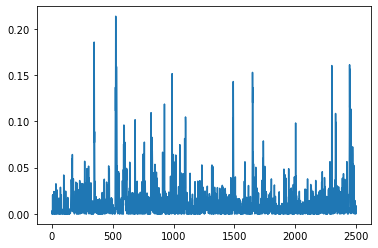

In [228]:
plt.plot(data['hellinger_dist'][:2500])